Step 1 – Install and Import Libraries

In [2]:
!pip install pyspark

In [3]:
import pandas as pd
import random
import time
from datetime import datetime
from pyspark.sql import SparkSession

Step 2 – Create Spark Session

In [4]:
spark = SparkSession.builder.appName("RealTimeLogProcessing").getOrCreate()

Step 3 – Create Log Data Generator

In [5]:
# Step 3 - Create Improved Log Data Generator

pages = [
    "/",
    "/products",
    "/cart",
    "/checkout",
    "/login",
    "/contact"
]

status_codes = [
    200, 200, 200, 200,
    201,
    400,
    404,
    500
]

def generate_log():

    return {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "ip_address": f"192.168.1.{random.randint(1, 254)}",
        "endpoint": random.choice(pages),
        "status_code": random.choice(status_codes),
        "response_time_ms": random.randint(50, 1500)
    }

Step 4 – Simulate Streaming Log Data

In [6]:
## Step 4 - Generate Log Data

logs = []

for i in range(100):

    log = generate_log()

    logs.append(log)

    print("New Log:", log)

    time.sleep(0.1)

New Log: {'timestamp': '2026-09-29 17:10:39', 'ip_address': '192.168.1.191', 'endpoint': '/products', 'status_code': 500, 'response_time_ms': 1314}
New Log: {'timestamp': '2026-09-29 17:10:39', 'ip_address': '192.168.1.72', 'endpoint': '/contact', 'status_code': 404, 'response_time_ms': 463}
New Log: {'timestamp': '2026-09-29 17:10:39', 'ip_address': '192.168.1.206', 'endpoint': '/login', 'status_code': 404, 'response_time_ms': 977}
New Log: {'timestamp': '2026-09-29 17:10:40', 'ip_address': '192.168.1.71', 'endpoint': '/contact', 'status_code': 201, 'response_time_ms': 1479}
New Log: {'timestamp': '2026-09-29 17:10:40', 'ip_address': '192.168.1.78', 'endpoint': '/checkout', 'status_code': 200, 'response_time_ms': 1250}
New Log: {'timestamp': '2026-09-29 17:10:40', 'ip_address': '192.168.1.120', 'endpoint': '/', 'status_code': 200, 'response_time_ms': 1292}
New Log: {'timestamp': '2026-09-29 17:10:40', 'ip_address': '192.168.1.18', 'endpoint': '/checkout', 'status_code': 201, 'response

In [7]:
# Step 5 - Create Pandas DataFrame

logs_df = pd.DataFrame(logs)

logs_df.head()

,timestamp,ip_address,endpoint,status_code,response_time_ms
0,2026-09-29 17:10:39,192.168.1.191,/products,500,1314
1,2026-09-29 17:10:39,192.168.1.72,/contact,404,463
2,2026-09-29 17:10:39,192.168.1.206,/login,404,977
3,2026-09-29 17:10:40,192.168.1.71,/contact,201,1479
4,2026-09-29 17:10:40,192.168.1.78,/checkout,200,1250


In [8]:
# Step 6 - Create PySpark DataFrame

spark_df = spark.createDataFrame(logs)

spark_df.show(10)

+---------+-------------+----------------+-----------+-------------------+
| endpoint|   ip_address|response_time_ms|status_code|          timestamp|
+---------+-------------+----------------+-----------+-------------------+
|/products|192.168.1.191|            1314|        500|2026-09-29 17:10:39|
| /contact| 192.168.1.72|             463|        404|2026-09-29 17:10:39|
|   /login|192.168.1.206|             977|        404|2026-09-29 17:10:39|
| /contact| 192.168.1.71|            1479|        201|2026-09-29 17:10:40|
|/checkout| 192.168.1.78|            1250|        200|2026-09-29 17:10:40|
|        /|192.168.1.120|            1292|        200|2026-09-29 17:10:40|
|/checkout| 192.168.1.18|            1138|        201|2026-09-29 17:10:40|
|   /login|192.168.1.142|             603|        200|2026-09-29 17:10:40|
|/checkout|192.168.1.249|            1323|        200|2026-09-29 17:10:40|
|   /login|192.168.1.220|            1306|        200|2026-09-29 17:10:40|
+---------+-------------+

In [9]:
# Step 7 - Basic Request Analytics

from pyspark.sql.functions import count, when, col

total_requests = spark_df.count()

successful_requests = spark_df.filter(
    col("status_code").isin(200, 201)
).count()

error_requests = spark_df.filter(
    col("status_code") >= 400
).count()

error_rate = (error_requests / total_requests) * 100

print("Total Requests:", total_requests)
print("Successful Requests:", successful_requests)
print("Error Requests:", error_requests)
print("Error Rate:", round(error_rate, 2), "%")

Total Requests: 100
Successful Requests: 53
Error Requests: 47
Error Rate: 47.0 %


In [10]:
# Step 8 - Requests by Endpoint

endpoint_requests = (
    spark_df
    .groupBy("endpoint")
    .count()
    .orderBy(col("count").desc())
)

endpoint_requests.show()

+---------+-----+
| endpoint|count|
+---------+-----+
|    /cart|   20|
|/checkout|   18|
|/products|   17|
| /contact|   16|
|        /|   15|
|   /login|   14|
+---------+-----+



In [11]:
# Step 9 - Error Analysis by Endpoint

error_by_endpoint = (
    spark_df
    .filter(col("status_code") >= 400)
    .groupBy("endpoint")
    .count()
    .orderBy(col("count").desc())
)

error_by_endpoint.show()

+---------+-----+
| endpoint|count|
+---------+-----+
|    /cart|    9|
|/products|    8|
|/checkout|    8|
|        /|    8|
|   /login|    7|
| /contact|    7|
+---------+-----+



In [12]:
# Step 10 - Status Code Analysis

status_analysis = (
    spark_df
    .groupBy("status_code")
    .count()
    .orderBy("status_code")
)

status_analysis.show()

+-----------+-----+
|status_code|count|
+-----------+-----+
|        200|   41|
|        201|   12|
|        400|   17|
|        404|   13|
|        500|   17|
+-----------+-----+



In [13]:
# Step 11 - Response Time Analysis

from pyspark.sql.functions import avg, max, min

response_time_stats = spark_df.select(
    avg("response_time_ms").alias("average_response_time"),
    max("response_time_ms").alias("maximum_response_time"),
    min("response_time_ms").alias("minimum_response_time")
)

response_time_stats.show()

+---------------------+---------------------+---------------------+
|average_response_time|maximum_response_time|minimum_response_time|
+---------------------+---------------------+---------------------+
|               858.02|                 1479|                   88|
+---------------------+---------------------+---------------------+



In [14]:
# Step 12 - Detect Slow Requests

slow_requests = (
    spark_df
    .filter(col("response_time_ms") > 1000)
    .orderBy(col("response_time_ms").desc())
)

slow_requests.show()

+---------+-------------+----------------+-----------+-------------------+
| endpoint|   ip_address|response_time_ms|status_code|          timestamp|
+---------+-------------+----------------+-----------+-------------------+
| /contact| 192.168.1.71|            1479|        201|2026-09-29 17:10:40|
| /contact| 192.168.1.86|            1469|        400|2026-09-29 17:10:41|
|    /cart|192.168.1.186|            1465|        400|2026-09-29 17:10:43|
|    /cart|192.168.1.191|            1449|        404|2026-09-29 17:10:45|
| /contact| 192.168.1.53|            1436|        200|2026-09-29 17:10:44|
|/checkout|192.168.1.247|            1433|        400|2026-09-29 17:10:44|
|/products| 192.168.1.89|            1429|        400|2026-09-29 17:10:48|
|/checkout| 192.168.1.74|            1429|        500|2026-09-29 17:10:48|
|/products|192.168.1.200|            1406|        200|2026-09-29 17:10:43|
|   /login|192.168.1.195|            1388|        400|2026-09-29 17:10:43|
|/checkout| 192.168.1.19|

In [15]:
# Step 13 - Anomaly Detection

anomalies = (
    spark_df
    .filter(
        (col("response_time_ms") > 1000) |
        (col("status_code") == 500)
    )
    .orderBy(col("response_time_ms").desc())
)

anomalies.show()

+---------+-------------+----------------+-----------+-------------------+
| endpoint|   ip_address|response_time_ms|status_code|          timestamp|
+---------+-------------+----------------+-----------+-------------------+
| /contact| 192.168.1.71|            1479|        201|2026-09-29 17:10:40|
| /contact| 192.168.1.86|            1469|        400|2026-09-29 17:10:41|
|    /cart|192.168.1.186|            1465|        400|2026-09-29 17:10:43|
|    /cart|192.168.1.191|            1449|        404|2026-09-29 17:10:45|
| /contact| 192.168.1.53|            1436|        200|2026-09-29 17:10:44|
|/checkout|192.168.1.247|            1433|        400|2026-09-29 17:10:44|
|/products| 192.168.1.89|            1429|        400|2026-09-29 17:10:48|
|/checkout| 192.168.1.74|            1429|        500|2026-09-29 17:10:48|
|/products|192.168.1.200|            1406|        200|2026-09-29 17:10:43|
|   /login|192.168.1.195|            1388|        400|2026-09-29 17:10:43|
|/checkout| 192.168.1.19|

In [16]:
# Step 14 - Count Detected Anomalies

anomaly_count = anomalies.count()

print("Total Anomalies Detected:", anomaly_count)

Total Anomalies Detected: 55


In [17]:
# Step 15 - Save Processed Logs

output_df = spark_df.toPandas()

output_df.to_csv("processed_logs (1).csv", index=False)

print("Processed logs saved successfully!")

Processed logs saved successfully!


In [18]:
# Step 16 - Save Detected Anomalies

anomalies.toPandas().to_csv("detected_anomalies.csv", index=False)

print("Anomaly results saved successfully!")

Anomaly results saved successfully!


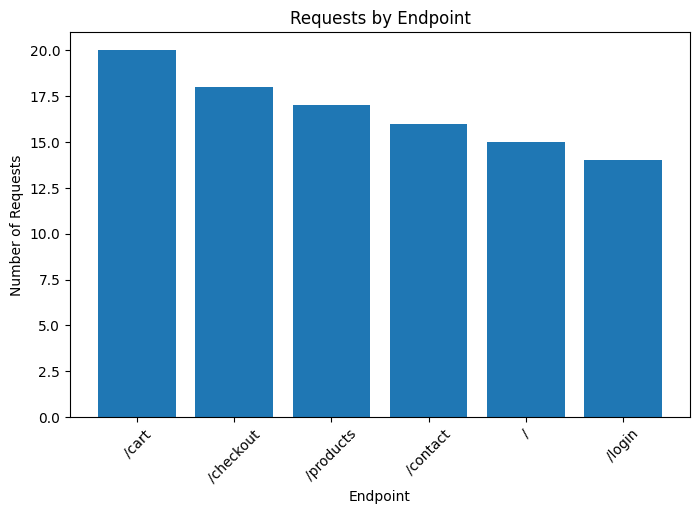

In [19]:
# Step 17 - Requests by Endpoint Visualization

import matplotlib.pyplot as plt

endpoint_data = (
    spark_df
    .groupBy("endpoint")
    .count()
    .orderBy(col("count").desc())
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.bar(endpoint_data["endpoint"], endpoint_data["count"])
plt.xlabel("Endpoint")
plt.ylabel("Number of Requests")
plt.title("Requests by Endpoint")
plt.xticks(rotation=45)
plt.show()

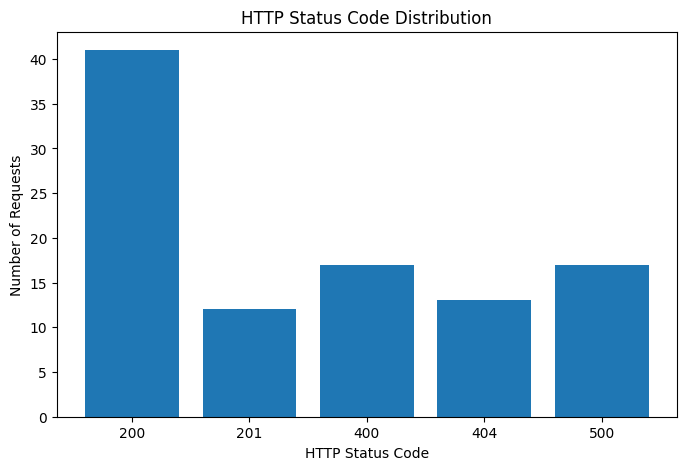

In [20]:
# Step 18 - HTTP Status Distribution

status_data = (
    spark_df
    .groupBy("status_code")
    .count()
    .orderBy("status_code")
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.bar(
    status_data["status_code"].astype(str),
    status_data["count"]
)
plt.xlabel("HTTP Status Code")
plt.ylabel("Number of Requests")
plt.title("HTTP Status Code Distribution")
plt.show()

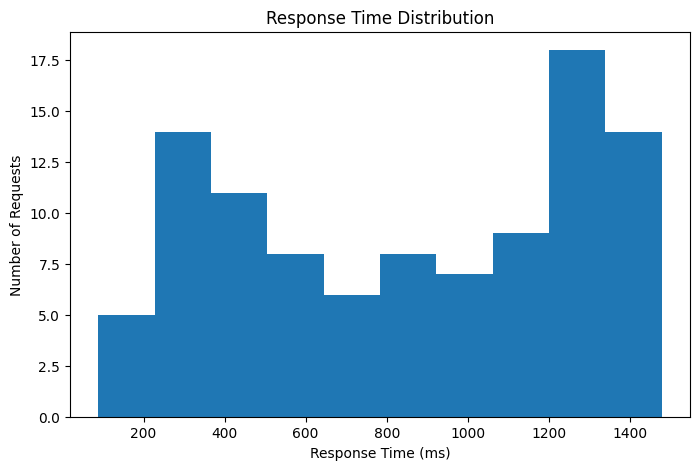

In [21]:
# Step 19 - Response Time Distribution

response_data = spark_df.select(
    "response_time_ms"
).toPandas()

plt.figure(figsize=(8, 5))
plt.hist(response_data["response_time_ms"], bins=10)
plt.xlabel("Response Time (ms)")
plt.ylabel("Number of Requests")
plt.title("Response Time Distribution")
plt.show()

In [22]:
# Step 20 - Explain Anomalies

from pyspark.sql.functions import when

anomalies_with_reason = (
    spark_df
    .filter(
        (col("response_time_ms") > 1000) |
        (col("status_code") == 500)
    )
    .withColumn(
        "anomaly_reason",
        when(
            (col("response_time_ms") > 1000) &
            (col("status_code") == 500),
            "Slow response + Server error"
        )
        .when(
            col("response_time_ms") > 1000,
            "Slow response"
        )
        .when(
            col("status_code") == 500,
            "Server error"
        )
    )
)

anomalies_with_reason.show()

+---------+-------------+----------------+-----------+-------------------+--------------------+
| endpoint|   ip_address|response_time_ms|status_code|          timestamp|      anomaly_reason|
+---------+-------------+----------------+-----------+-------------------+--------------------+
|/products|192.168.1.191|            1314|        500|2026-09-29 17:10:39|Slow response + S...|
| /contact| 192.168.1.71|            1479|        201|2026-09-29 17:10:40|       Slow response|
|/checkout| 192.168.1.78|            1250|        200|2026-09-29 17:10:40|       Slow response|
|        /|192.168.1.120|            1292|        200|2026-09-29 17:10:40|       Slow response|
|/checkout| 192.168.1.18|            1138|        201|2026-09-29 17:10:40|       Slow response|
|/checkout|192.168.1.249|            1323|        200|2026-09-29 17:10:40|       Slow response|
|   /login|192.168.1.220|            1306|        200|2026-09-29 17:10:40|       Slow response|
|/products|192.168.1.226|             47

In [23]:
# Step 21 - Save Anomaly Report

anomalies_with_reason.toPandas().to_csv(
    "detected_anomalies.csv",
    index=False
)

print("Anomaly report saved successfully!")

Anomaly report saved successfully!


In [24]:
# Step 22 - Prepare Dashboard Data

dashboard_df = spark_df.toPandas()

dashboard_df.head()

,endpoint,ip_address,response_time_ms,status_code,timestamp
0,/products,192.168.1.191,1314,500,2026-09-29 17:10:39
1,/contact,192.168.1.72,463,404,2026-09-29 17:10:39
2,/login,192.168.1.206,977,404,2026-09-29 17:10:39
3,/contact,192.168.1.71,1479,201,2026-09-29 17:10:40
4,/checkout,192.168.1.78,1250,200,2026-09-29 17:10:40


In [25]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 87.5 MB/s eta 0:00:00


In [31]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Real-Time Log Analytics",
    layout="wide"
)

st.title("Real-Time Log Analytics Dashboard")

# Load processed logs
df = pd.read_csv("processed_logs (1).csv")

# Basic metrics
total_requests = len(df)
successful_requests = len(df[df["status_code"].isin([200, 201])])
error_requests = len(df[df["status_code"] >= 400])
error_rate = (error_requests / total_requests) * 100

# Metrics
col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Requests", total_requests)
col2.metric("Successful Requests", successful_requests)
col3.metric("Error Requests", error_requests)
col4.metric("Error Rate", f"{error_rate:.2f}%")

st.subheader("Requests by Endpoint")

endpoint_counts = df["endpoint"].value_counts()

st.bar_chart(endpoint_counts)

st.subheader("HTTP Status Code Distribution")

status_counts = df["status_code"].value_counts().sort_index()

st.bar_chart(status_counts)

st.subheader("Response Time Analysis")

st.write(
    f"Average Response Time: {df['response_time_ms'].mean():.2f} ms"
)

st.write(
    f"Maximum Response Time: {df['response_time_ms'].max()} ms"
)

st.subheader("Detected Anomalies")

anomalies = df[
    (df["response_time_ms"] > 1000) |
    (df["status_code"] == 500)
]

st.dataframe(anomalies)

Overwriting app.py


In [27]:
!ls -l app.py processed_logs.csv detected_anomalies.csv

-rw-r--r-- 1 root root 1300 Sep 29 17:11 app.py
-rw-r--r-- 1 root root 3659 Sep 29 17:11 detected_anomalies.csv
-rw-r--r-- 1 root root 5002 Sep 29 17:11 processed_logs.csv


In [28]:
!pip install pyngrok -q

In [29]:
%%writefile requirements.txt

pandas
pyspark
streamlit
matplotlib

Overwriting requirements.txt
